**Minimum Back Propogation Nodes**

To motivate the study of multivariable loss functions, consider $f(x_0,x_1,x_2,x_3...x_n)$.

 How does a nudge in $x_n$ effect $f$?

In [106]:
# graphing library for visualizing the computation graph

# brew install graphviz
# pip install graphviz
from graphviz import Digraph
import numpy as np
import random

In [107]:
# a node class with gradient tracking
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0

        # implement backpropagation
        self._backward = lambda: None

        self.label = label  # optional name for graphviz visualization
        # internal variables used for autograd graph construction
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        # define back prop for addition
        def _backward():
                self.grad+=out.grad
                other.grad+=out.grad
        out._backward=_backward
        return out

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __pow__(self,other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        # create a new Value node if other is not a value object
        other = other if isinstance(other, Value) else Value(other)
        # create a new Value node for the product of the two values
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
             self.grad+=other.data*out.grad
             other.grad+=self.data*out.grad
        out._backward=_backward
        return out

    # tanh(x) = (e^x - e^-x) / (e^x + e^-x) = 2 / (1 + e^-2x) - 1 = 1 - 2 / (1 + e^2x) = 1 - 2 * sigmoid(-2x) = 2 * sigmoid(2x) - 1
    # dtanh(x)/dx = 1 - tanh^2(x)
    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
             self.grad+=(1 - out.data**2) * out.grad
        out._backward=_backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build(child)
                topo.append(node)

        build(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [108]:
# trace the graph of nodes and edges starting from the root node
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

# draw the graph of nodes and edges starting from the root node
def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [109]:
# verify that the Value class is defined in the current module and print its constructor signature
import inspect
print(inspect.signature(Value.__init__))
print(Value.__module__)

(self, data, _children=(), _op='', label='')
__main__


## Chain Rule ##

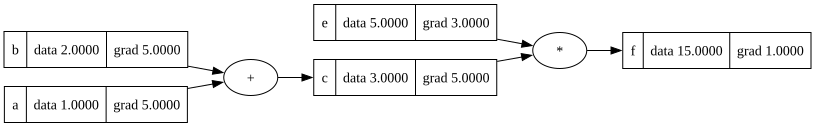

In [110]:
# a simple example

a = Value(1.0); a.label = 'a'
b = Value(2.0); b.label = 'b'
c = Value(3.0); c.label = 'c'
d = Value(4.0); d.label = 'd'
e = Value(5.0); e.label = 'e'

c = a + b; c.label = 'c'

f = c * e; f.label = 'f'
f.grad=1
f._backward()

# df/db = df/dc * dc/db

c._backward()

draw_dot(f)

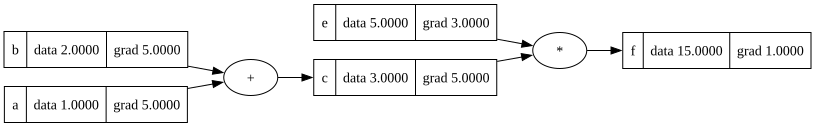

In [111]:
# initialize backpropagation by setting the gradient of the output node to 1.0
f.grad = 1.0

# compute first layer of backprop, df/de and df/dc
# f=c*e
# df/dc = e = 5, df/de = c = 3
c.grad=5
e.grad=3

draw_dot(f)

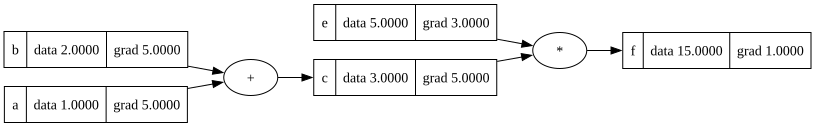

In [112]:
# c = a + b
# consider chain rule
# df/da = df/dc * dc/da , df/db = df/dc * dc/db
# df/da = 5 * 1, df/db = 5 * 1

a.grad=5
b.grad=5

draw_dot(f)

## Total Derivative ##

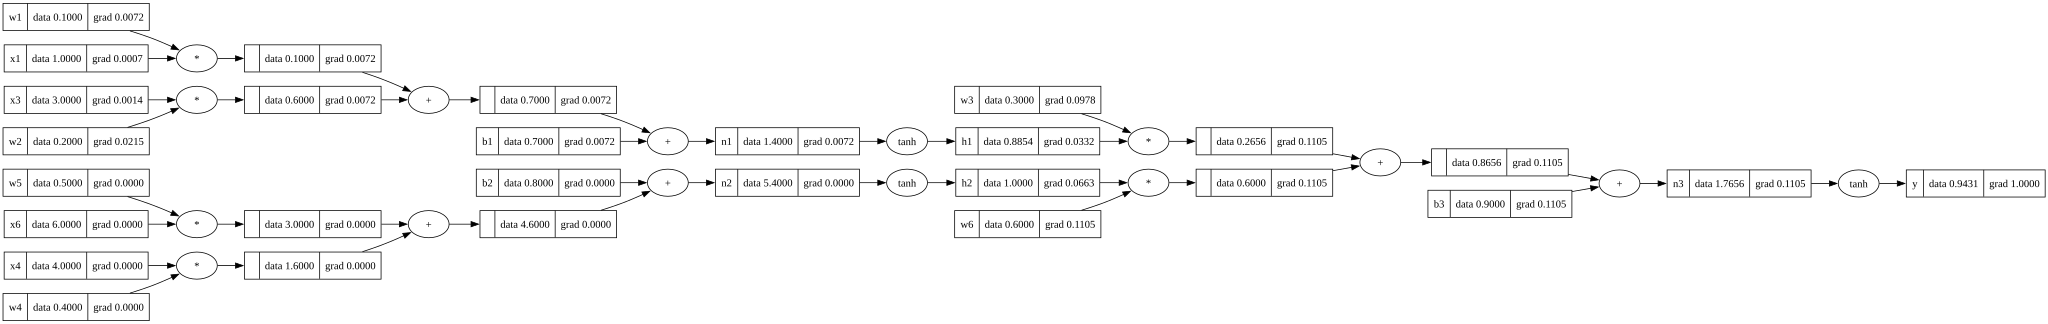

In [113]:
# minimal 2-layer neural network: hidden layer (2 neurons) -> output layer (1 neuron)
# tanh activation applied at every layer, 6 inputs, 6 weights, 3 biases

# input
x1 = Value(1.0); x1.label = 'x1'
x2 = Value(2.0); x2.label = 'x2'
x3 = Value(3.0); x3.label = 'x3'
x4 = Value(4.0); x4.label = 'x4'
x5 = Value(5.0); x5.label = 'x5'
x6 = Value(6.0); x6.label = 'x6'

# weights
w1 = Value(0.1); w1.label = 'w1'
w2 = Value(0.2); w2.label = 'w2'
w3 = Value(0.3); w3.label = 'w3'
w4 = Value(0.4); w4.label = 'w4'
w5 = Value(0.5); w5.label = 'w5'
w6 = Value(0.6); w6.label = 'w6'

# bias
b1 = Value(0.7); b1.label = 'b1'
b2 = Value(0.8); b2.label = 'b2'
b3 = Value(0.9); b3.label = 'b3'

# --- layer 1 (hidden layer, 2 neurons) ---

# hidden neuron 1: takes x1, x3
n1 = w1*x1 + w2*x3 + b1; n1.label = 'n1'
h1 = n1.tanh(); h1.label = 'h1'

# hidden neuron 2: takes x4, x6
n2 = w4*x4 + w5*x6 + b2; n2.label = 'n2'
h2 = n2.tanh(); h2.label = 'h2'

# --- layer 2 (output layer, 1 neuron) ---

# output neuron: takes h1, h2 (the hidden layer's activations)
n3 = w3*h1 + w6*h2 + b3; n3.label = 'n3'
y = n3.tanh(); y.label = 'y'

y.backward()
draw_dot(y)

Manually calculating the gradients of a 2-layer network is tedious and error-prone. Instead, we can use the chain rule to compute the gradients automatically. This is the essence of backpropagation.

## Verifying Against PyTorch ##

Rebuild the exact same 2-layer network in PyTorch (same values, same connectivity) and compare `.grad` on every leaf against the `Value` engine above.

In [114]:
import torch

# use float64 to match numpy's default precision in the Value engine above,
# otherwise PyTorch's default float32 tensors will disagree in the last few digits
dt = torch.float64

# --- same inputs, weights, biases as the Value network above ---
x1t = torch.tensor(1.0, requires_grad=True, dtype=dt)
x2t = torch.tensor(2.0, requires_grad=True, dtype=dt)
x3t = torch.tensor(3.0, requires_grad=True, dtype=dt)
x4t = torch.tensor(4.0, requires_grad=True, dtype=dt)
x5t = torch.tensor(5.0, requires_grad=True, dtype=dt)
x6t = torch.tensor(6.0, requires_grad=True, dtype=dt)

w1t = torch.tensor(0.1, requires_grad=True, dtype=dt)
w2t = torch.tensor(0.2, requires_grad=True, dtype=dt)
w3t = torch.tensor(0.3, requires_grad=True, dtype=dt)
w4t = torch.tensor(0.4, requires_grad=True, dtype=dt)
w5t = torch.tensor(0.5, requires_grad=True, dtype=dt)
w6t = torch.tensor(0.6, requires_grad=True, dtype=dt)

b1t = torch.tensor(0.7, requires_grad=True, dtype=dt)
b2t = torch.tensor(0.8, requires_grad=True, dtype=dt)
b3t = torch.tensor(0.9, requires_grad=True, dtype=dt)

# --- same graph: hidden layer (2 neurons) -> output layer (1 neuron), tanh everywhere ---
n1t = w1t * x1t + w2t * x3t + b1t
h1t = torch.tanh(n1t)

n2t = w4t * x4t + w5t * x6t + b2t
h2t = torch.tanh(n2t)

n3t = w3t * h1t + w6t * h2t + b3t
yt = torch.tanh(n3t)

yt.backward()

# --- compare forward output ---
print(f"y (Value)   = {y.data:.10f}")
print(f"y (PyTorch) = {yt.item():.10f}")
print(f"match: {abs(y.data - yt.item()) < 1e-9}\n")

# --- compare gradients on every leaf that feeds the graph ---
pairs = [
    ('x1', x1, x1t), ('x3', x3, x3t), ('x4', x4, x4t), ('x6', x6, x6t),
    ('w1', w1, w1t), ('w2', w2, w2t), ('w3', w3, w3t),
    ('w4', w4, w4t), ('w5', w5, w5t), ('w6', w6, w6t),
    ('b1', b1, b1t), ('b2', b2, b2t), ('b3', b3, b3t),
]

print(f"{'param':<6}{'Value.grad':>15}{'torch.grad':>15}{'match':>8}")
for name, v, t in pairs:
    match = abs(v.grad - t.grad.item()) < 1e-9
    print(f"{name:<6}{v.grad:>15.10f}{t.grad.item():>15.10f}{str(match):>8}")

assert all(abs(v.grad - t.grad.item()) < 1e-9 for _, v, t in pairs), "mismatch found!"
print("\nAll gradients match — backprop implementation verified against PyTorch autograd.")

y (Value)   = 0.9431230730
y (PyTorch) = 0.9431230730
match: True

param      Value.grad     torch.grad   match
x1       0.0007166678   0.0007166678    True
x3       0.0014333355   0.0014333355    True
x4       0.0000021643   0.0000021643    True
x6       0.0000027053   0.0000027053    True
w1       0.0071666776   0.0071666776    True
w2       0.0215000328   0.0215000328    True
w3       0.0978480630   0.0978480630    True
w4       0.0000216426   0.0000216426    True
w5       0.0000324639   0.0000324639    True
w6       0.1105143602   0.1105143602    True
b1       0.0071666776   0.0071666776    True
b2       0.0000054107   0.0000054107    True
b3       0.1105188692   0.1105188692    True

All gradients match — backprop implementation verified against PyTorch autograd.


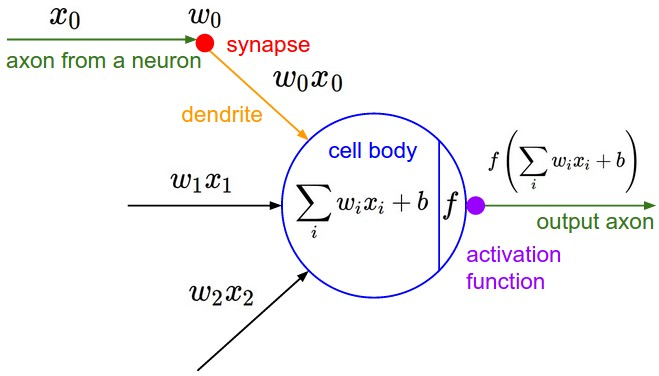

## From `Value` to `MLP`

The `Value` class is the building block for automatic differentiation. Each scalar stores its numeric value, remembers the operations that created it, and accumulates a gradient during backpropagation.

A neural network is made by composing many `Value` objects:

1. A **`Neuron`** stores one weight per input and one bias. It computes a weighted sum, then applies `tanh`.
2. A **`Layer`** groups several neurons that receive the same input vector.
3. An **`MLP`** stacks layers. The output of one layer becomes the input to the next.

The important connection is that the network does not need a separate backpropagation implementation. Multiplication, addition, and `tanh` create `Value` nodes, so calling `.backward()` on the final prediction automatically propagates gradients through the entire MLP.

In [115]:
# A neuron turns several Value inputs into one scalar output.
class Neuron:

  def __init__(self, nin):
    # One learnable weight per input, plus one learnable bias.
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # Weighted sum followed by the nonlinearity.
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    # A layer applies several neurons to the same input.
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    # Build a stack such as 3 inputs -> 4 -> 4 -> 1 output.
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    # Feed each layer's output into the next layer.
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    # Flatten all layer parameters for one training loop.
    return [p for layer in self.layers for p in layer.parameters()]

In [116]:
# One example has three input features.
x = [2.0, 3.0, -1.0]

# The final 1 means n(x) returns one scalar prediction per example.
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.45009658089895616, grad=0)

In [117]:
#draw_dot(n(x))

In [118]:
n.layers[0].neurons[0].parameters()

[Value(data=0.2236078109677886, grad=0),
 Value(data=0.6384697413203271, grad=0),
 Value(data=-0.04626402753642589, grad=0),
 Value(data=0.23014908791401556, grad=0)]

In [119]:
# Four training examples, each with three input features.
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

# The target for each example is one scalar.
ys = [1.0, -1.0, -1.0, 1.0]


In [120]:
# The number of runs
batch_number=100

# η too small would slow convergence, too large would lead to overshoot and divergence
stepsize = 0.01

# Common mistakes from Karpathy's video
# 1, Didn't try overfit a single batch
# 2, Forgot to toggle train/eval mode for the net
# 3, Forgot to .zero_grad() in pytorch before .backward()
# 4, Passed soft maxed outputs to a loss that expects raw logits

for i in range(batch_number):
    # Run the network once for each input example.
    ypred = [n(x) for x in xs]

    # Compare each prediction with its target.
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # zero grad
    for i in n.parameters():
        i.grad=0

    # Target y and predicted y

    # Backpropagate the total loss through the whole MLP.
    print(i, " : loss = ", loss.data)
    loss.backward()

    for p in n.parameters():
        p.data += -stepsize * p.grad

Value(data=0.6303701573518206, grad=0)  : loss =  6.4139817791346045
Value(data=0.6495559740904525, grad=0)  : loss =  5.852615463416508
Value(data=0.6641267097131057, grad=0)  : loss =  5.402621756130719
Value(data=0.672783238658743, grad=0)  : loss =  5.048824568356266
Value(data=0.6756084253550572, grad=0)  : loss =  4.751982168364465
Value(data=0.6732127762235356, grad=0)  : loss =  4.488540182142756
Value(data=0.6663397002196366, grad=0)  : loss =  4.258393258047567
Value(data=0.6559773693303704, grad=0)  : loss =  4.066986523281581
Value(data=0.6433602179010812, grad=0)  : loss =  3.9097707365914633
Value(data=0.629604787807208, grad=0)  : loss =  3.777388516310117
Value(data=0.6154750433655588, grad=0)  : loss =  3.662622429412659
Value(data=0.6014250274447158, grad=0)  : loss =  3.560936149122573
Value(data=0.5877085299669715, grad=0)  : loss =  3.469319375122783
Value(data=0.5744591502537328, grad=0)  : loss =  3.3854816517271282
Value(data=0.5617373829501144, grad=0)  : loss 

In [121]:
ypred

[Value(data=0.8554537576322975, grad=-0.28909248473540505),
 Value(data=-0.8709561795249097, grad=0.25808764095018066),
 Value(data=-0.7702625517800191, grad=0.45947489643996176),
 Value(data=0.8075544967413387, grad=-0.38489100651732255)]

In [122]:
ys

[1.0, -1.0, -1.0, 1.0]

In [ ]:
# Four training examples, each with three input features.
'''xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]'''

# Increase the batch number and see the difference between test and pred
# Explain why does vectors that are not true x can get better estimation
# error than the true x?
xt=[
    [2,3,-1],
    [2,3,0],
    [1,1,-1],
    [1,1,1],
]

testpred = [n(x) for x in xt]
testpred

[Value(data=0.8566726750255645, grad=0),
 Value(data=0.769933286303835, grad=0),
 Value(data=0.8090212323523502, grad=0),
 Value(data=-0.7289418313731537, grad=0)]

## Conclusion ##

Go to BinaryOpsKernel in pytorch for production tanh cpu implementation.